### Bayesian Regression

In [207]:
# pip install pymc arviz

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import pandas as pd
import pymc as pm
import arviz as az
import arviz_plots as azp

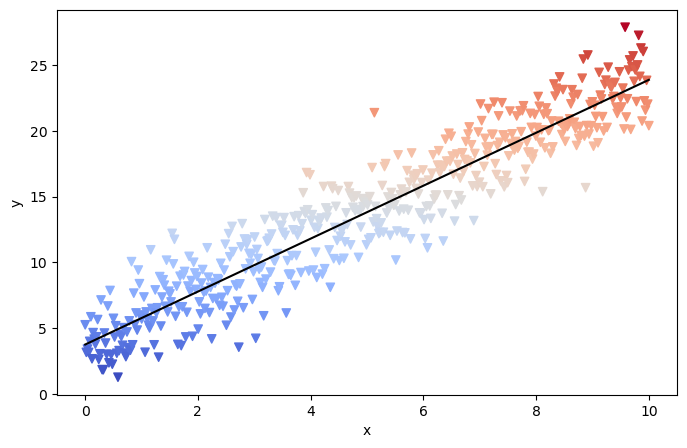

In [208]:
# Create some random data to fit 
inter = 4
slope = 2

x = np.linspace(0, 10, 500)
y = inter + slope * x + np.random.normal(loc=0, scale=2, size=len(x))

# Simple linear regression
reg = np.polyfit(x, y, deg=1)
inter = reg[1]
slope = reg[0]

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.scatter(x, y, c=y, marker='v', cmap='coolwarm')
ax.plot(x, inter + slope * x, color='black')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

We obtain as results the slope and the intecept of the regression line via OLS

In [209]:
# Bayesian model for linear regression

with pm.Model() as model:
    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=20)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    # Linear model
    mu = alpha + beta * x

    # Likelihood
    y_obs = pm.Normal("y", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


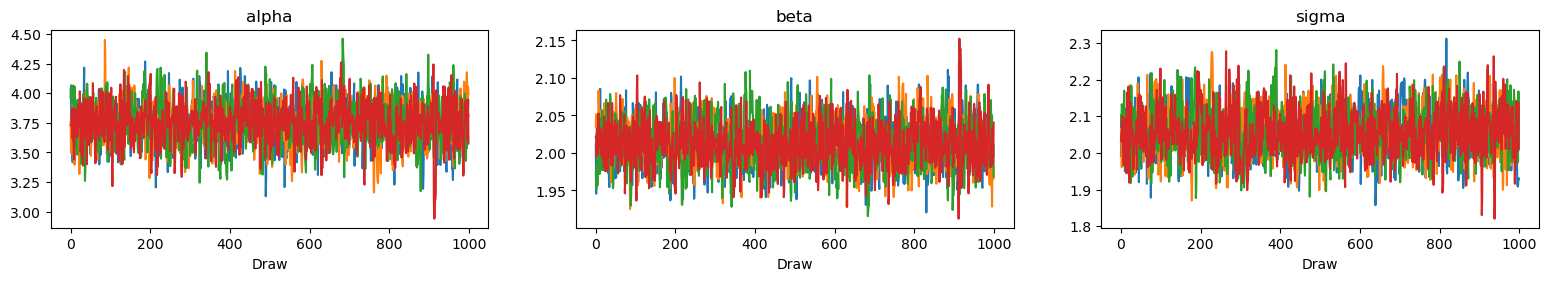

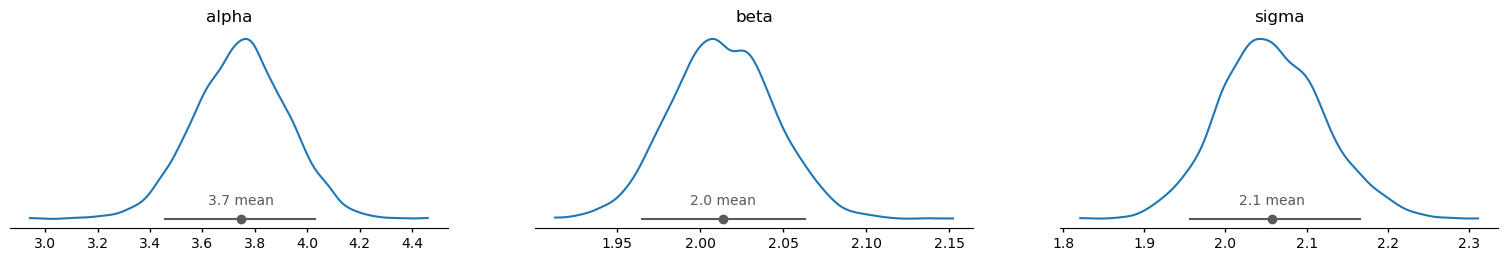

In [210]:
# Summary of posterior distributions

az.summary(
    trace,
    var_names=["alpha", "beta", "sigma"],
)

az.plot_trace(
    trace,
    var_names=["alpha", "beta", "sigma"]
)
plt.show()

azp.plot_dist(
    trace,
    var_names=["alpha", "beta", "sigma"],
    group="posterior"
)
plt.show()

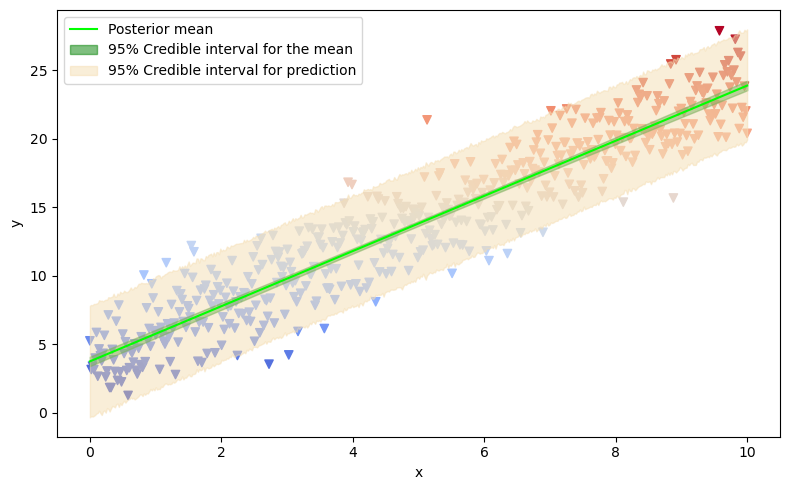

In [211]:
# Grab posterior distributions
posterior_samples = trace["posterior"].to_dataset().stack(sample=("chain", "draw"))
alpha_samples = posterior_samples["alpha"].values
beta_samples = posterior_samples["beta"].values
sigma_samples = posterior_samples["sigma"].values

# Generate regression lines, one per draw
reg_lines = alpha_samples[:, None] + beta_samples[:, None] * x[None, :] # Regression lines: (nDraws, x.size)
reg_lines_mean = reg_lines.mean(axis=0)                                 # Mean: (x.size,)
reg_lines_ci = np.quantile(reg_lines, [0.025, 0.975], axis=0)           # Credible interval: (2, x.size)

# For the prediction interval we need to incorporate the noise parameter
reg_lines_pred = reg_lines + np.random.normal(loc=0, scale=sigma_samples[:, None], size=reg_lines.shape)
reg_lines_pred = np.quantile(reg_lines_pred, [0.025, 0.975], axis=0)    # Prediction interval: (2, x.size)


# Plot resulting regression lines
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.scatter(x, y, c=y, marker='v', cmap='coolwarm')
ax.plot(x, reg_lines_mean, color='lime', label='Posterior mean')
ax.fill_between(x, 
                reg_lines_ci[0, :], 
                reg_lines_ci[1, :], 
                color='green', 
                alpha=0.5,
                label='95% Credible interval for the mean')
ax.fill_between(x, 
                reg_lines_pred[0, :], 
                reg_lines_pred[1, :], 
                color='wheat', 
                alpha=0.5,
                label='95% Credible interval for prediction')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

In this Bayesian linear regression model, we provide the full dataset $(x, y)$ to the model at once. The model assumes that each observed value $y_i$ is generated from a normal distribution centered around a linear prediction $\mu_i$, with residual uncertainty controlled by $\sigma$. The linear prediction is

$$
\mu_i = \alpha + \beta x_i
$$

and the likelihood for each observation is

$$
y_i \sim \mathcal{N}(\alpha + \beta x_i, \sigma)
$$

Because all observations are assumed conditionally independent given the parameters, the full likelihood is the product of the likelihoods of all individual data points:

$$
p(y \mid x, \alpha, \beta, \sigma) = 
\prod_{i=1}^{n}
\mathcal{N}(y_i \mid \alpha + \beta x_i, \sigma)
$$

The priors define our initial beliefs about the parameters before seeing the data:

$$
\alpha \sim \mathcal{N}(0, 20) \\
\beta \sim \mathcal{N}(0, 10) \\
\sigma \sim \text{HalfNormal}(10)
$$

After observing the data, Bayes' rule combines the prior information with the likelihood from all data points to obtain the posterior distribution:

$$
p(\alpha, \beta, \sigma \mid x, y)
\propto
p(y \mid x, \alpha, \beta, \sigma)
p(\alpha)
p(\beta)
p(\sigma)
$$

Therefore, the posterior distributions of $\alpha$, $\beta$, and $\sigma$ are updated using all available data. The result is not a single best value for each parameter, but a full distribution describing which parameter values are plausible after seeing the data.

In practice, this posterior distribution is usually too difficult to compute exactly, especially because it may not have a simple closed-form solution. This is why PyMC uses Markov Chain Monte Carlo, or MCMC. MCMC is a sampling method that generates many plausible values of $\alpha$, $\beta$, and $\sigma$ from the posterior distribution. Instead of solving the posterior analytically, MCMC constructs a Markov chain whose long-run behavior follows the target posterior distribution. In PyMC, the sampler repeatedly proposes new parameter values, evaluates how well those values explain the observed data together with the priors, and then decides whether to move toward those values. After enough iterations, the sampled values approximate the posterior distribution.

The `tune=1000` step is used for adaptation: the sampler learns how to explore the posterior efficiently. These tuning samples are not usually used for inference. The `draws=1000` step then collects posterior samples after tuning. Since `chains=4`, PyMC runs four independent MCMC chains, which helps check whether the sampler is consistently exploring the same posterior distribution. The final `trace` therefore contains samples from the joint posterior distribution

$$
p(\alpha, \beta, \sigma \mid x, y)
$$

and these samples can be used to estimate posterior means, credible intervals, regression lines, uncertainty bands, and posterior predictive distributions.


### Real Data Bayesian Regression

In [212]:
raw = pd.read_csv('~/quant_finance/python_for_finance/tr_eikon_eod_data.csv', index_col=0, parse_dates=True).dropna()
data = raw[['GDX', 'GLD']]

data = data / data.iloc[0] # Normalize so time series start at 1
data.head()

,GDX,GLD
Date,,
2010-01-04,1.000000,1.000000
2010-01-05,1.009642,0.999089
2010-01-06,1.034165,1.015574
2010-01-07,1.029134,1.009290
2010-01-08,1.044645,1.014299


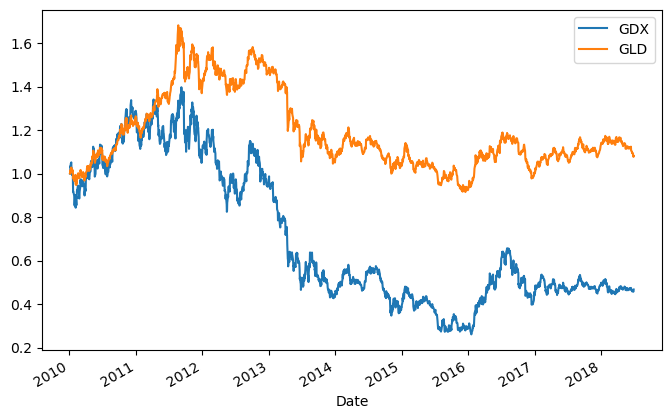

In [213]:
data.plot(figsize=(8,5))
plt.show()

In [214]:
data.corr()

,GDX,GLD
GDX,1.00000,0.71539
GLD,0.71539,1.00000


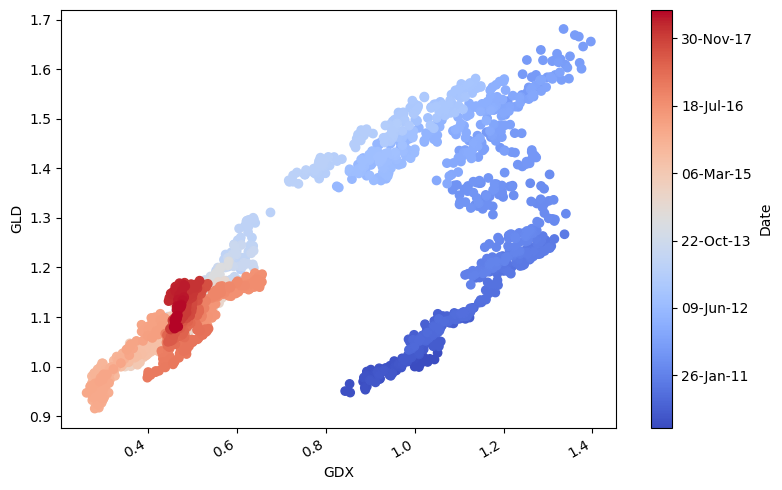

In [215]:
dates = pd.to_datetime(data.index)

# Convert dates to Matplotlib numeric date format
dates_num = mdates.date2num(dates)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sc = ax.scatter(
    data["GDX"],
    data["GLD"],
    marker="o",
    c=dates_num,
    cmap="coolwarm"
)
ax.set_xlabel("GDX")
ax.set_ylabel("GLD")
# Add colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Date")
# Format colorbar ticks as dates
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%d-%b-%y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [216]:
with pm.Model() as model:
    # Prior
    alpha = pm.Normal('alpha', mu=0, sd=20)
    beta = pm.Normal('beta', mu=0, sd=20)
    sigma = pm.HalfNormal('sigma', mu=0, sd=20)

    # Likelihood
    mu = alpha + beta * data['GDX'].values
    y_obs = pm.Normal("y", mu=mu, sigma=sigma, observed=data['GLD'].values)

    # Sampling
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


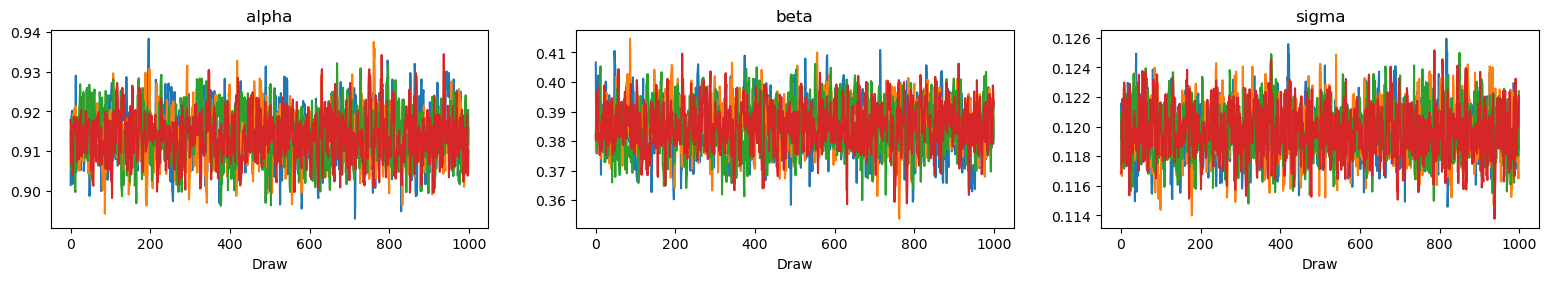

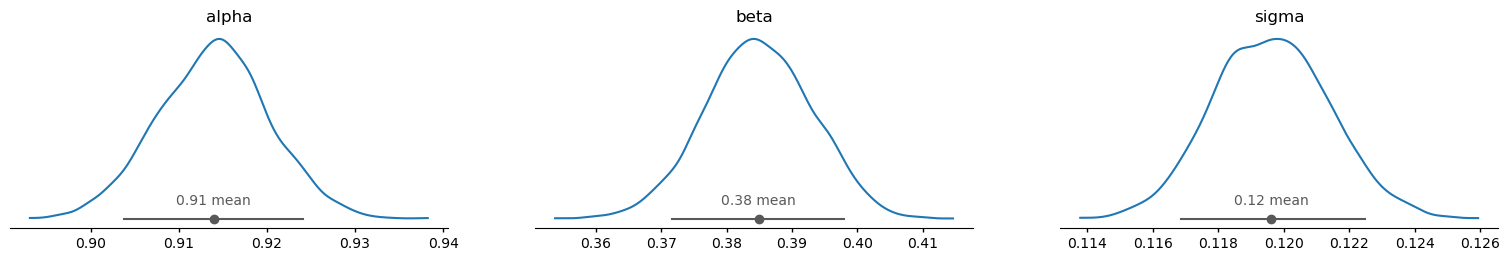

In [217]:
# Summary of posterior distributions 

az.summary(
    trace,
    var_names=["alpha", "beta", "sigma"],
)

az.plot_trace(
    trace,
    var_names=["alpha", "beta", "sigma"]
)
plt.show()

azp.plot_dist(
    trace,
    var_names=["alpha", "beta", "sigma"],
    group="posterior"
)
plt.show()

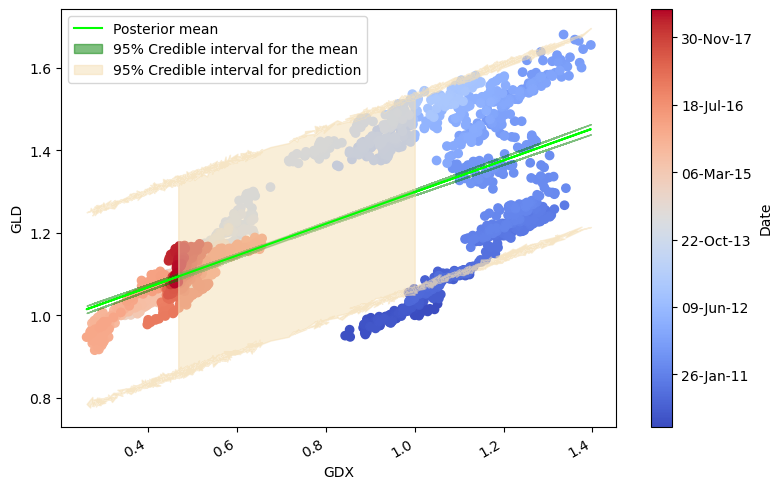

In [223]:
# Grab posterior distributions
posterior_samples = trace["posterior"].to_dataset().stack(sample=("chain", "draw"))
alpha_samples = posterior_samples["alpha"].values
beta_samples = posterior_samples["beta"].values
sigma_samples = posterior_samples["sigma"].values

# Generate regression lines
reg_lines = alpha_samples[:, None] + beta_samples[:, None] * data['GDX'].values[None, :]
reg_lines_mean = reg_lines.mean(axis=0)
reg_lines_ci = np.quantile(reg_lines, [0.025, 0.975], axis=0)
reg_lines_pred = reg_lines + np.random.normal(loc=0, scale=sigma_samples[:, None], size=reg_lines.shape)
reg_lines_pred = np.quantile(reg_lines_pred, [0.025, 0.975], axis=0)


# Plot resulting regression lines
fig, ax = plt.subplots(1, 1, figsize=(8,5))
sc = ax.scatter(
    data["GDX"],
    data["GLD"],
    marker="o",
    c=dates_num,
    cmap="coolwarm"
)
ax.plot(data["GDX"], reg_lines_mean, color='lime', label='Posterior mean')
ax.fill_between(data['GDX'], 
                reg_lines_ci[0, :], 
                reg_lines_ci[1, :], 
                color='green', 
                alpha=0.5,
                label='95% Credible interval for the mean')
ax.fill_between(data['GDX'], 
                reg_lines_pred[0, :], 
                reg_lines_pred[1, :], 
                color='wheat', 
                alpha=0.5,
                label='95% Credible interval for prediction')
ax.set_xlabel("GDX")
ax.set_ylabel("GLD")
# Add colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Date")
# Format colorbar ticks as dates
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%d-%b-%y"))
fig.autofmt_xdate()
plt.legend()
plt.tight_layout()
plt.show()

### Updating Estimates Over Time

In finance we can improve the previous model by considering that new information allows for better estimates over time. This can be implemented with the regression parameters being not only random variables but following some type of random walk over time

In [224]:
nObs = 2100
x_used = np.asarray(data['GDX'].values[:nObs], dtype=float)
y_used = np.asarray(data['GLD'].values[:nObs], dtype=float)
time_idx = np.arange(nObs)

with pm.Model() as grw_model:

    # Random-walk step sizes
    sigma_alpha = pm.Exponential("sigma_alpha", lam=10.0)
    sigma_beta = pm.Exponential("sigma_beta", lam=10.0)
    # Observation noise
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    # Initial distributions for random walks
    alpha_init = pm.Normal.dist(mu=0.0, sigma=1.0)
    beta_init = pm.Normal.dist(mu=0.0, sigma=1.0)

    # Time-varying intercept and slope
    alpha = pm.GaussianRandomWalk(
        "alpha",
        sigma=sigma_alpha,
        init_dist=alpha_init,
        shape=nObs
    )

    beta = pm.GaussianRandomWalk(
        "beta",
        sigma=sigma_beta,
        init_dist=beta_init,
        shape=nObs
    )

    # Time-varying mean
    mu = alpha + beta * x_used

    # Likelihood
    y_obs = pm.Normal(
        "y",
        mu=mu,
        sigma=sigma,
        observed=y_used
    )

    # Inference
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Rewrite failure due to: local_subtensor_merge_slice
node: Subtensor{i}(Subtensor{start:stop}.0, 0)
TRACEBACK:
Traceback (most recent call last):
  File "/Users/giacomo/miniforge3/lib/python3.12/site-packages/pytensor/graph/rewriting/basic.py", line 1920, in process_node
    replacements = node_rewriter.transform(
                   ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/giacomo/miniforge3/lib/python3.12/site-packages/pytensor/graph/rewriting/basic.py", line 993, in transform
    return self.fn(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/giacomo/miniforge3/lib/python3.12/site-packages/pytensor/tensor/rewriting/subtensor.py", line 973, in local_subtensor_merge_slice
    return _local_subtensor_merge_rewrite(fgraph, node, merge_integer_index=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/giacomo/miniforge3/lib/python3.12/site-packages/pytensor/tensor/rewriting/subtenso

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 83 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [259]:
# Summary of posterior distributions

az.summary(
    trace,
    var_names=["alpha", "beta", "sigma_alpha", "sigma_beta", "sigma"],
)

# Grab posterior distributions
posterior = trace["posterior"].to_dataset()
alpha_samples = posterior["alpha"].stack(sample=("chain", "draw")).values
beta_samples = posterior["beta"].stack(sample=("chain", "draw")).values
sigma_samples = posterior["sigma"].stack(sample=("chain", "draw")).values

alpha_mean = alpha_samples.mean(axis=1)
beta_mean = beta_samples.mean(axis=1)

alpha_ci = np.quantile(alpha_samples, [0.025, 0.975], axis=1)
beta_ci = np.quantile(beta_samples, [0.025, 0.975], axis=1)

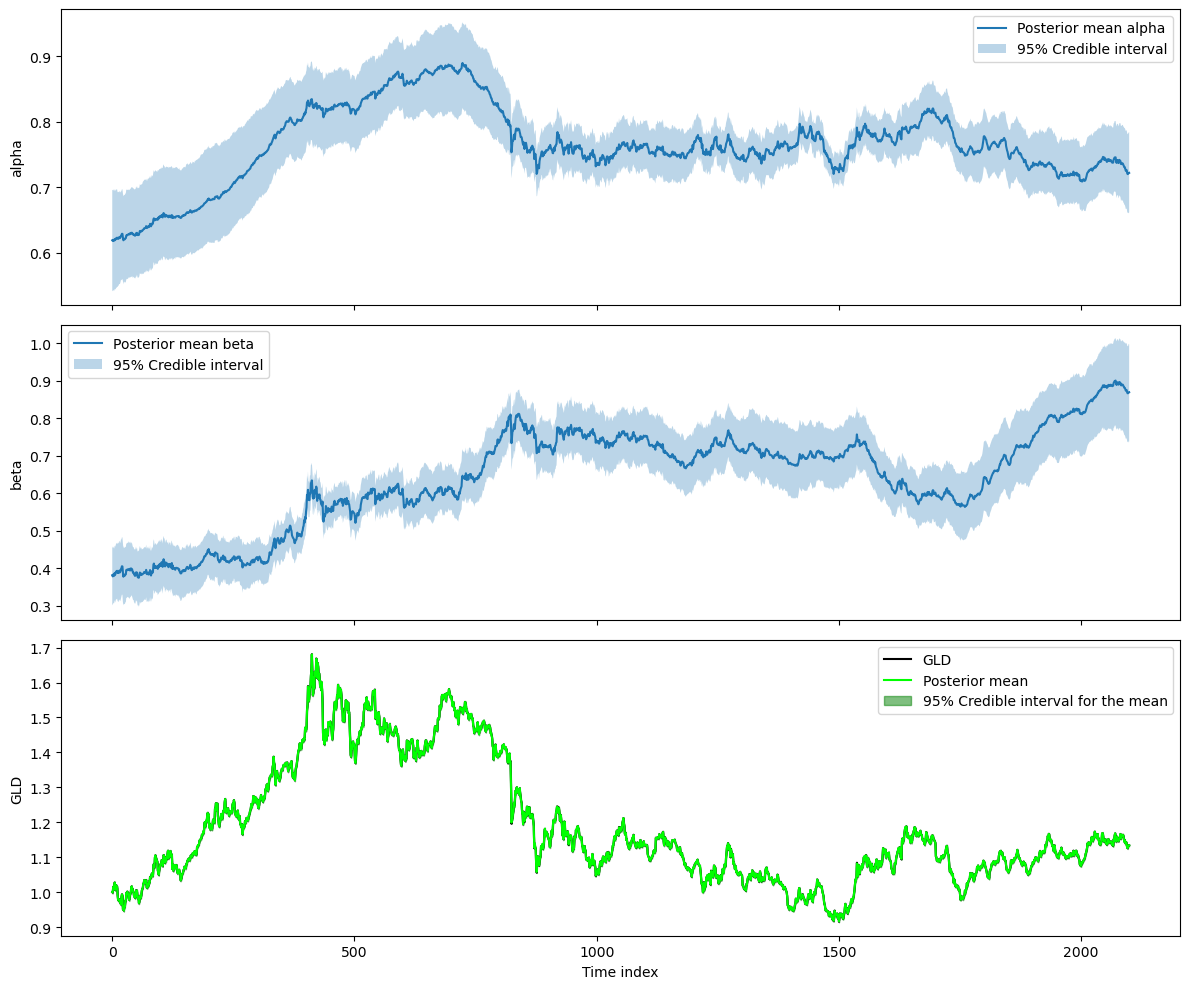

In [268]:
y_pred = alpha_samples + beta_samples * x_used[:, None]
y_pred_mean = y_pred.mean(axis=1)
y_pred_ci = np.quantile(y_pred, [0.025, 0.975], axis=1)


# Plot posterior distributions as time series
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(time_idx, alpha_mean, label="Posterior mean alpha")
axes[0].fill_between(
    time_idx,
    alpha_ci[0, :],
    alpha_ci[1, :],
    alpha=0.3,
    label="95% Credible interval"
)
axes[0].set_ylabel("alpha")
axes[0].legend()


axes[1].plot(time_idx, beta_mean, label="Posterior mean beta")
axes[1].fill_between(
    time_idx,
    beta_ci[0, :],
    beta_ci[1, :],
    alpha=0.3,
    label="95% Credible interval"
)
axes[1].set_ylabel("beta")
axes[1].legend()


axes[2].plot(time_idx, y_used, color='black', label='GLD')
y_pred = alpha_samples + beta_samples * x_used[:, None]
y_pred_mean = y_pred.mean(axis=1)
y_pred_ci = np.quantile(y_pred, [0.025, 0.975], axis=1)
axes[2].plot(time_idx, y_pred_mean, color='lime', label='Posterior mean')
axes[2].fill_between(time_idx, y_pred_ci[0, :], y_pred_ci[1, :], color='green', alpha=0.5, label='95% Credible interval for the mean')
axes[2].set_xlabel("Time index")
axes[2].set_ylabel("GLD")
axes[2].legend()
plt.tight_layout()
plt.show()

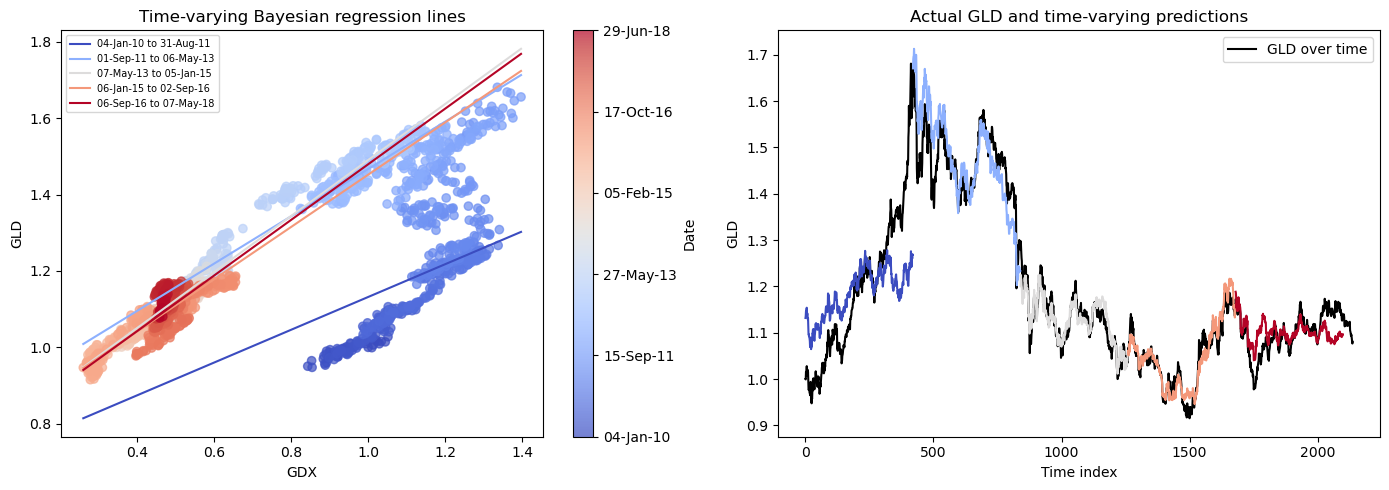

In [277]:
# Plot regression lines over multiple periods
nPeriods = 5
period_edges = np.linspace(0, nObs, nPeriods + 1, dtype=int)

alphas = [alpha_mean[start:end].mean() for start,end in zip(period_edges[:], period_edges[1:])]
betas = [beta_mean[start:end].mean() for start,end in zip(period_edges[:], period_edges[1:])]

x_grid = np.linspace(data['GDX'].min(), data['GDX'].max(), 200)
line_cmap = plt.get_cmap("coolwarm")


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Time-colored scatter: GDX vs GLD
sc = ax[0].scatter(
    data["GDX"],
    data["GLD"],
    marker="o",
    c=dates_num,
    cmap="coolwarm",
    alpha=0.7
)

# Time axis
time_axis = np.arange(len(data))
# Actual GLD through time
ax[1].plot(
    time_axis,
    data["GLD"].values,
    color="black",
    lw=1.5,
    label="GLD over time"
)

for i in range(nPeriods):
    start = period_edges[i]
    end = period_edges[i + 1]

    alpha = alphas[i]
    beta = betas[i]
    color = line_cmap(i / (nPeriods - 1))
    label = (
        f"{dates[start].strftime('%d-%b-%y')} "
        f"to {dates[end - 1].strftime('%d-%b-%y')}"
    )

    # Regression line in GDX-GLD space
    reg_line = alpha + beta * x_grid
    ax[0].plot(
        x_grid,
        reg_line,
        color=color,
        lw=1.5,
        label=label
    )

    # Predicted GLD through time
    x_period = data["GDX"].iloc[start:end].values
    y_pred = alpha + beta * x_period

    ax[1].plot(
        time_axis[start:end],
        y_pred,
        color=color,
        lw=1.5
    )

# Left panel
ax[0].set_xlabel("GDX")
ax[0].set_ylabel("GLD")
ax[0].set_title("Time-varying Bayesian regression lines")

# Right panel
ax[1].set_xlabel("Time index")
ax[1].set_ylabel("GLD")
ax[1].set_title("Actual GLD and time-varying predictions")
ax[1].legend()

# Colorbar for scatter dates
cbar = fig.colorbar(sc, ax=ax[0])
cbar.set_label("Date")

tick_locs = np.linspace(dates_num.min(), dates_num.max(), 6)
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([
    mdates.num2date(t).strftime("%d-%b-%y")
    for t in tick_locs
])

ax[0].legend(fontsize=7, loc="best")

plt.tight_layout()
plt.show()

In this model, we are no longer fitting a standard Bayesian linear regression with one fixed intercept $\alpha$ and one fixed slope $\beta$. Instead, we are fitting a **Bayesian time-varying linear regression**, where both the intercept and the slope are allowed to change over time. For each time point $t$, the model assumes

$$
y_t \sim \mathcal{N}(\alpha_t + \beta_t x_t, \sigma)
$$

where $\alpha_t$ is the intercept at time $t$, $\beta_t$ is the slope at time $t$, and $\sigma$ is the observation noise. The important difference from ordinary Bayesian linear regression is that $\alpha_t$ and $\beta_t$ are not constant across all observations. Instead, they evolve through time according to Gaussian random walks:

$$
\alpha_t \sim \mathcal{N}(\alpha_{t-1}, \sigma_\alpha) \\
\beta_t \sim \mathcal{N}(\beta_{t-1}, \sigma_\beta)
$$

This means that the intercept and slope at one time point are expected to be close to their values at the previous time point, but they are allowed to drift gradually. The parameters $\sigma_\alpha$ and $\sigma_\beta$ control how much the intercept and slope can change from one observation to the next. Small values imply smooth, slowly changing parameters, while larger values allow faster changes over time. In this code, the priors

$$
\sigma_\alpha \sim \text{Exponential}(10) \\
\sigma_\beta \sim \text{Exponential}(10)
$$

favor small random-walk step sizes, meaning the model initially prefers smooth parameter evolution unless the data provide evidence for stronger changes.

The likelihood combines all observations:

$$
p(y \mid x, \alpha_{1:T}, \beta_{1:T}, \sigma) =
\prod_{t=1}^{T}
\mathcal{N}(y_t \mid \alpha_t + \beta_t x_t, \sigma)
$$

where $T = 2100$ in this example. Therefore, the model estimates full time series of parameters:

$$
\alpha_1, \alpha_2, \dots, \alpha_T \\
\beta_1, \beta_2, \dots, \beta_T
$$

rather than single global values. Because this posterior distribution contains thousands of correlated unknown parameters, it is too complex to compute analytically. PyMC therefore uses Markov Chain Monte Carlo, or MCMC, to generate samples from the posterior distribution:

$$
p(\alpha_{1:T}, \beta_{1:T}, \sigma_\alpha, \sigma_\beta, \sigma \mid x, y)
$$

Each MCMC sample contains one possible trajectory for the intercept, one possible trajectory for the slope, and values for the noise parameters. After sampling, the regression relationship changes over time, including posterior uncertainty around $\alpha_t$, $\beta_t$, and the predicted mean

$$
\mu_t = \alpha_t + \beta_t x_t
$$

This model is useful when the relationship between $x$ and $y$ is expected to evolve over time, such as a financial beta changing across market regimes.
